# Proyecto I: Reconocimiento de comandos de voz

Curso de Inteligencia Artificial, Instituto Tecnológico de Costa Rica.

Notebook único del proyecto. Funciona en Google Colab y en escritorio.

## 0. Configuración

Constantes del **contrato de entrada** (`docs/contrato_entrada.md`). Si alguna cambia, la app móvil tiene que cambiar igual.

In [9]:
import os, sys, math, wave, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

IN_COLAB = "google.colab" in sys.modules

# --- Rutas ---
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_TAR = Path("/content/drive/MyDrive/ProyectoIA_ComandosDeVoz/archive.tar")   # los 10 comandos + listas
    DATA_DIR = Path("/content/archive")   # se extrae aquí en la celda 0.1
    OUT_DIR  = Path("/content/drive/MyDrive/ProyectoIA_ComandosDeVoz/resultados")
    CACHE_DIR = Path("/content/cache")   # los .pt (~620 MB) van al disco temporal de Colab, no al Drive
else:
    # Escritorio: carpeta con los audios (variable DATA_DIR o la ruta por defecto)
    DATA_DIR = Path(os.environ.get("DATA_DIR", Path.home() / "Downloads" / "archive"))
    OUT_DIR  = Path.cwd().parent / "resultados" if Path.cwd().name == "notebooks" else Path.cwd() / "resultados"
    CACHE_DIR = OUT_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# --- Comandos ---
COMMANDS = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
LABEL_TO_IDX = {c: i for i, c in enumerate(COMMANDS)}

# --- Contrato de entrada ---
SAMPLE_RATE = 16_000            # Hz
NUM_SAMPLES = SAMPLE_RATE * 1   # 1 segundo
N_FFT       = 480               # ventana de 30 ms
WIN_LENGTH  = 480
HOP_LENGTH  = 160               # salto de 10 ms
N_MELS      = 40
N_FRAMES    = NUM_SAMPLES // HOP_LENGTH + 1   # 101 columnas de tiempo
F_MIN, F_MAX = 20.0, 8_000.0
LOG_EPS     = 1e-6

# --- División ---
SPLITS = ["train", "val", "test"]

# --- Semillas ---
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()

print("Colab:", IN_COLAB)
print("Datos:", DATA_DIR, "| existe:", DATA_DIR.exists())
print("Resultados:", OUT_DIR)

Colab: False
Datos: C:\Users\jenki\Downloads\archive | existe: True
Resultados: c:\Users\jenki\Desktop\IA\resultados


### 0.1 Copiar el dataset a Colab (solo Colab)

Leer 38 mil audios sueltos desde Google Drive es muy lento. Por eso el dataset (solo los 10 comandos y las listas) está en Drive como **un solo archivo** `archive.tar`. Esta celda lo copia al disco temporal de Colab y lo extrae, lo que tarda un par de minutos. Si ya se extrajo en esta sesión, no se repite.

En escritorio esta celda no hace nada: se usan los audios de `DATA_DIR`.

In [10]:
import shutil, tarfile

if IN_COLAB and not (DATA_DIR / "testing_list.txt").exists():
    local_tar = Path("/content/archive.tar")
    print("Copiando archive.tar desde Drive...")
    shutil.copy(DATA_TAR, local_tar)
    print("Extrayendo...")
    with tarfile.open(local_tar) as tar:
        tar.extractall("/content", filter="data")   # crea /content/archive
    local_tar.unlink()   # libera espacio en el disco de Colab

print("Datos listos en:", DATA_DIR, "| existe:", DATA_DIR.exists())


Datos listos en: C:\Users\jenki\Downloads\archive | existe: True


## 1. Datos y preprocesamiento

### 1.1 Filtrar el dataset a los 10 comandos

Speech Commands v0.02 trae 35 palabras más ruido de fondo. Solo se usan las 10 carpetas de los comandos.

In [11]:
rows = []
for c in COMMANDS:
    for p in sorted((DATA_DIR / c).glob("*.wav")):
        rows.append({"path": f"{c}/{p.name}", "label": c, "label_idx": LABEL_TO_IDX[c],
                     "speaker": p.name.split("_nohash_")[0]})
df = pd.DataFrame(rows)

# Si falta algún comando (por ejemplo, la subida a Drive no terminó), avisar de una vez
por_comando = df["label"].value_counts().reindex(COMMANDS, fill_value=0)
faltan = list(por_comando[por_comando == 0].index)
assert not faltan, f"No hay audios de: {faltan}. Revisa que esas carpetas estén completas en {DATA_DIR}"

print(f"{len(df)} audios de {len(COMMANDS)} comandos")
df.head()

38546 audios de 10 comandos


,path,label,label_idx,speaker
0,yes/004ae714_nohash_0.wav,yes,0,004ae714
1,yes/004ae714_nohash_1.wav,yes,0,004ae714
2,yes/00970ce1_nohash_0.wav,yes,0,00970ce1
3,yes/00f0204f_nohash_0.wav,yes,0,00f0204f
4,yes/00f0204f_nohash_1.wav,yes,0,00f0204f


### 1.2 División con las listas oficiales

El dataset trae dos listas: `validation_list.txt` y `testing_list.txt`. Los audios que no aparecen en ninguna van a entrenamiento. Las listas se construyeron asignando cada **hablante** a un solo conjunto, así una misma voz no aparece en dos conjuntos y el modelo no se evalúa con personas que ya escuchó al entrenar.

In [12]:
def read_list(name):
    return set((DATA_DIR / name).read_text().split())

val_files  = read_list("validation_list.txt")
test_files = read_list("testing_list.txt")

df["split"] = "train"
df.loc[df["path"].isin(val_files),  "split"] = "val"
df.loc[df["path"].isin(test_files), "split"] = "test"

# Verificación: ningún hablante en más de un conjunto
repetidos = df.groupby("speaker")["split"].nunique()
print("Hablantes en más de un conjunto:", int((repetidos > 1).sum()))

resumen = pd.DataFrame({
    "hablantes": df.groupby("split")["speaker"].nunique(),
    "audios": df["split"].value_counts(),
}).reindex(SPLITS)
resumen["% audios"] = (100 * resumen["audios"] / len(df)).round(1)
display(resumen)

df.to_csv(OUT_DIR / "splits.csv", index=False)
print("Guardado:", OUT_DIR / "splits.csv")

Hablantes en más de un conjunto: 0


,hablantes,audios,% audios
split,,,
train,2008,30769,79.8
val,245,3703,9.6
test,239,4074,10.6


Guardado: c:\Users\jenki\Desktop\IA\resultados\splits.csv


### 1.3 Balance de clases

split,train,val,test,total
label,,,,
yes,3228,397,419,4044
no,3130,406,405,3941
up,2948,350,425,3723
down,3134,377,406,3917
left,3037,352,412,3801
right,3019,363,396,3778
on,3086,363,396,3845
off,2970,373,402,3745
stop,3111,350,411,3872


Porcentaje de cada comando dentro de su conjunto (ideal 10 %):
  mín 9.5 %  |  máx 11.0 %


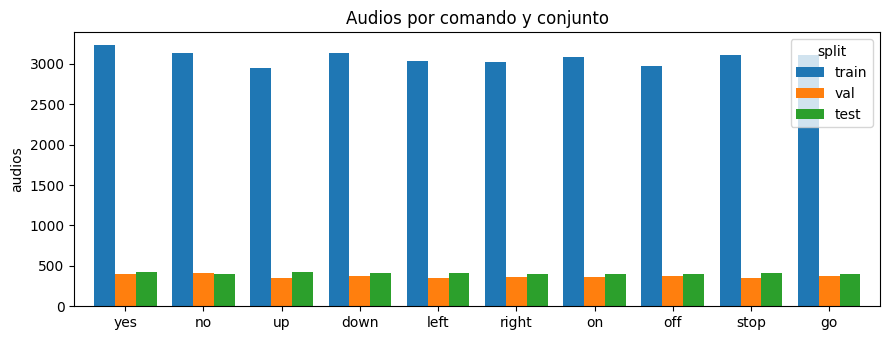

In [13]:
balance = pd.crosstab(df["label"], df["split"]).reindex(index=COMMANDS, columns=SPLITS)
display(balance.assign(total=balance.sum(axis=1)))

pct = 100 * balance / balance.sum()
print("Porcentaje de cada comando dentro de su conjunto (ideal 10 %):")
print(f"  mín {pct.values.min():.1f} %  |  máx {pct.values.max():.1f} %")

ax = balance.plot.bar(figsize=(9, 3.5), width=0.8)
ax.set_xlabel(""); ax.set_ylabel("audios"); ax.set_title("Audios por comando y conjunto")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(OUT_DIR / "balance_clases.png", dpi=150); plt.show()

### 1.4 Dataset crudo: audio → espectrograma log-mel

Pasos del contrato de entrada:

1. Leer WAV PCM 16 bits mono a 16 kHz y pasar a float32 en [-1, 1] (`int16 / 32768`).
2. Rellenar con ceros al final o recortar a 16 000 muestras (1 s).
3. STFT con ventana de Hann de 480 muestras, salto de 160, `center=True`, relleno *reflect*.
4. Potencia `|STFT|²`.
5. Banco de 40 filtros mel triangulares (escala HTK, 20–8000 Hz, sin normalización).
6. `log(mel + 1e-6)`.

Resultado: una matriz de **40 × 101** por audio.

In [14]:
def load_wav(path):
    with wave.open(str(path), "rb") as f:
        assert f.getnchannels() == 1 and f.getsampwidth() == 2 and f.getframerate() == SAMPLE_RATE, path
        pcm = np.frombuffer(f.readframes(f.getnframes()), dtype="<i2")
    return torch.from_numpy(pcm.astype(np.float32) / 32768.0)

def fix_length(wav, n=NUM_SAMPLES):
    return wav[:n] if wav.numel() >= n else torch.nn.functional.pad(wav, (0, n - wav.numel()))

def hz_to_mel(f): return 2595.0 * math.log10(1.0 + f / 700.0)
def mel_to_hz(m): return 700.0 * (10.0 ** (m / 2595.0) - 1.0)

def mel_filterbank(n_freqs=N_FFT // 2 + 1, n_mels=N_MELS, f_min=F_MIN, f_max=F_MAX, sr=SAMPLE_RATE):
    all_freqs = torch.linspace(0, sr // 2, n_freqs, dtype=torch.float64)
    f_pts = mel_to_hz(torch.linspace(hz_to_mel(f_min), hz_to_mel(f_max), n_mels + 2, dtype=torch.float64))
    f_diff = f_pts[1:] - f_pts[:-1]
    slopes = f_pts[None, :] - all_freqs[:, None]
    down = -slopes[:, :-2] / f_diff[:-1]
    up   =  slopes[:, 2:]  / f_diff[1:]
    return torch.clamp(torch.minimum(down, up), min=0.0).float()   # (n_freqs, n_mels)

MEL_FB = mel_filterbank()
WINDOW = torch.hann_window(WIN_LENGTH)

def log_mel(wav):
    spec = torch.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH, window=WINDOW,
                      center=True, pad_mode="reflect", return_complex=True)
    mel = MEL_FB.T @ (spec.abs() ** 2)
    return torch.log(mel + LOG_EPS)   # (40, 101) para un audio, o (B, 40, 101) para un lote de B audios

def audio_to_logmel(path):
    return log_mel(fix_length(load_wav(path)))

print("Forma:", tuple(audio_to_logmel(DATA_DIR / df["path"].iloc[0]).shape))

Forma: (40, 101)


Se calcula el log-mel de todos los audios y se guarda un archivo por conjunto (`raw_train.pt`, `raw_val.pt`, `raw_test.pt`) con `X` de forma `(N, 40, 101)` e `y` de forma `(N,)`. Si los archivos ya existen se cargan en vez de recalcular.

Para que sea rápido con pocos recursos:
- los audios se leen **en paralelo** (varios a la vez), porque leer archivos desde Drive o Kaggle es lo más lento;
- los espectrogramas se calculan **en lotes de 1000 audios** con una sola llamada a `torch.stft`, en vez de uno por uno.

El resultado es idéntico al de procesar cada audio por separado, y la memoria usada es solo la de un lote a la vez.

In [15]:
CONTRATO = {"sample_rate": SAMPLE_RATE, "num_samples": NUM_SAMPLES, "n_fft": N_FFT, "win_length": WIN_LENGTH,
            "hop_length": HOP_LENGTH, "n_mels": N_MELS, "f_min": F_MIN, "f_max": F_MAX, "log_eps": LOG_EPS}

from concurrent.futures import ThreadPoolExecutor

LOTE = 1000      # audios por lote: más grande = más rápido pero más memoria
HILOS = 16       # archivos leídos al mismo tiempo

def load_fixed(rel):
    return fix_length(load_wav(DATA_DIR / rel))

def build_split(split):
    archivo = CACHE_DIR / f"raw_{split}.pt"
    sub = df[df.split == split]
    if archivo.exists():
        d = torch.load(archivo)
        # Solo se reutiliza si se hizo con el mismo contrato y los mismos audios
        if d.get("contrato") == CONTRATO and d.get("paths") == list(sub["path"]):
            print(f"{split}: cargado de {archivo.name}")
            return d["X"], d["y"]
        print(f"{split}: el archivo guardado no coincide con los datos actuales, se recalcula")
    paths = list(sub["path"])
    X = torch.empty((len(paths), N_MELS, N_FRAMES))
    with ThreadPoolExecutor(HILOS) as pool:
        for inicio in range(0, len(paths), LOTE):
            ondas = torch.stack(list(pool.map(load_fixed, paths[inicio:inicio + LOTE])))   # (lote, 16000)
            X[inicio:inicio + len(ondas)] = log_mel(ondas)                                  # (lote, 40, 101)
            print(f"  {split}: {inicio + len(ondas)}/{len(paths)}", end="\r")
    y = torch.tensor(sub["label_idx"].to_numpy(), dtype=torch.int64)
    torch.save({"X": X, "y": y, "paths": list(sub["path"]), "contrato": CONTRATO}, archivo)
    print(f"{split}: {tuple(X.shape)} → {archivo.name}")
    return X, y

raw = {s: build_split(s) for s in SPLITS}

train: cargado de raw_train.pt
val: cargado de raw_val.pt
test: cargado de raw_test.pt


### 1.5 Ejemplos de espectrogramas (referencia)

Cinco espectrogramas del conjunto de entrenamiento, uno por comando, guardados como PNG en `resultados/ejemplos_espectrogramas/`. Son solo para ver cómo luce cada imagen; el modelo usa los números de los `.pt`, no estos PNG.

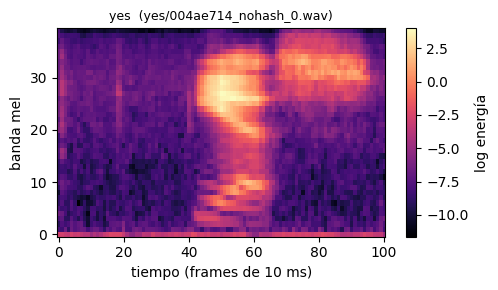

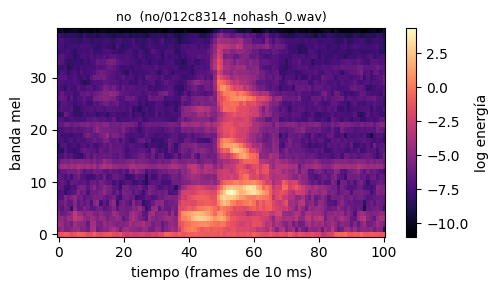

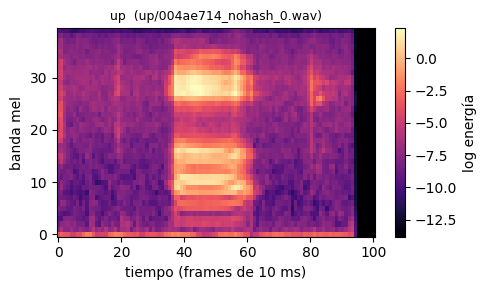

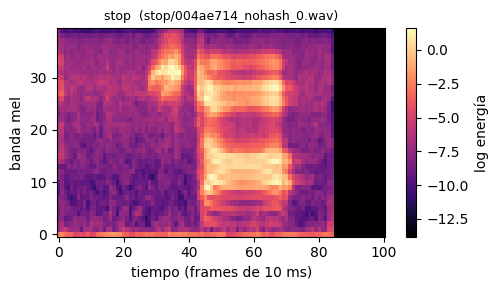

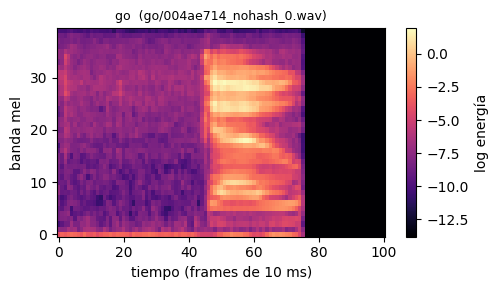

Guardados en: c:\Users\jenki\Desktop\IA\resultados\ejemplos_espectrogramas


In [16]:
EJEMPLOS_DIR = OUT_DIR / "ejemplos_espectrogramas"
EJEMPLOS_DIR.mkdir(exist_ok=True)

X_train, y_train = raw["train"]
train_paths = df[df.split == "train"]["path"].tolist()   # mismo orden que X_train

for c in ["yes", "no", "up", "stop", "go"]:
    i = y_train.tolist().index(LABEL_TO_IDX[c])            # primer audio de ese comando
    fig, ax = plt.subplots(figsize=(5, 3))
    im = ax.imshow(X_train[i], origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"{c}  ({train_paths[i]})", fontsize=9)
    ax.set_xlabel("tiempo (frames de 10 ms)"); ax.set_ylabel("banda mel")
    fig.colorbar(im, ax=ax, label="log energía")
    fig.tight_layout()
    fig.savefig(EJEMPLOS_DIR / f"{c}.png", dpi=150)
    plt.show()

print("Guardados en:", EJEMPLOS_DIR)